In [15]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from xgboost.sklearn import XGBRegressor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone

In [16]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp100 = market.retrieve("sp100")
market.disconnect()

In [29]:
cycle_days = 365
holding_period = 5
tickers = sp100["ticker"].values
weeks = 5
factors = [f"rolling_{days}" for days in [5,10,20,60,100]]
positions = len(sp100["GICS Sector"].unique())
cycles = 5

In [30]:
market.connect()
prices = []
for cycle in range(cycles,0,-1):
    training_start_date = (datetime.now() - timedelta(days=cycle_days*cycle)).astimezone(timezone.utc)
    training_end_date = (datetime.now()-timedelta(days=cycle_days*(cycle-1))).astimezone(timezone.utc)
    prediction_end_date = (datetime.now()-timedelta(days=cycle_days*(cycle-2))).astimezone(timezone.utc)
    for ticker in tqdm(tickers,desc="model_prep"):
        try:
            ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
            ticker_prices.sort_values("date",inplace=True)
            training_data = ticker_prices[["year","date","ticker","adjclose"]].groupby(["date","ticker"]).mean().reset_index()
            # for i in range(weeks):
            #     training_data[str(i)] = training_data["adjclose"].shift(i)
            for days in [5,10,20,60,100]:
                training_data[f"rolling_{days}"] = training_data["adjclose"].rolling(window=days).mean()
            training_data["y"] = training_data["adjclose"].shift(-holding_period)
            model_data = training_data[(training_data["date"]<=training_end_date) & (training_data["date"]>=training_start_date)].dropna().reset_index(drop=True)
            simulation = training_data[(training_data["date"]<=prediction_end_date) & (training_data["date"]>=training_end_date)].dropna().reset_index(drop=True)
            model = XGBRegressor(booster="gblinear",learning_rate=1,objective="reg:squarederror",verbosity = 0)
            model.fit(model_data[factors],model_data["y"])
            simulation["prediction"] = model.predict(simulation[factors])
            ticker_prices = processor.merge(ticker_prices,simulation,on=["year","date","ticker"]).dropna()
            ticker_prices.sort_values("date",inplace=True)
            ticker_prices["predicted_return"] = (ticker_prices["prediction"] - ticker_prices["adjclose"]) / ticker_prices["adjclose"]
            ticker_prices["signal"] = ticker_prices["predicted_return"]
            ticker_prices["buy_price"] = ticker_prices["adjclose"].shift(-1)
            ticker_prices["buy_date"] = ticker_prices["date"].shift(-1)
            ticker_prices["sell_price"] = ticker_prices["adjclose"].shift(-holding_period)
            ticker_prices["sell_date"] = ticker_prices["date"].shift(-holding_period)
            ticker_prices["abs"] = ticker_prices["signal"].abs()
            ticker_prices["direction"] = ticker_prices["signal"] / ticker_prices["abs"]
            ticker_prices["return"] = (ticker_prices["sell_price"] - ticker_prices["buy_price"]) / ticker_prices ["buy_price"] * (1/positions) * ticker_prices["direction"]
            prices.append(ticker_prices)
        except Exception as e:
            continue
market.disconnect()

model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:20<00:00,  4.88it/s]


In [31]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp100,on="ticker")

In [32]:
## backtest
trades = sim[sim["weekday"]==4]
trades = trades[trades["week"] % int(holding_period/5) == 0]
trades = trades.sort_values("abs").groupby(["date","GICS Sector"]).first().reset_index()

In [33]:
trades = processor.column_date_processing(trades[["date","abs","direction","ticker","GICS Sector","adjclose","return"]])

In [34]:
portfolio = trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio = portfolio[portfolio["date"]<portfolio["date"].max()]
portfolio["return"] = portfolio["return"] + 1
portfolio["cr"] = portfolio["return"].cumprod()

In [35]:
portfolio

,date,return,cr
0,2019-12-06 00:00:00+00:00,0.995341,0.995341
1,2019-12-13 00:00:00+00:00,0.981586,0.977013
2,2019-12-20 00:00:00+00:00,0.996355,0.973452
3,2019-12-27 00:00:00+00:00,0.997045,0.970575
4,2020-01-03 00:00:00+00:00,0.997673,0.968317
...,...,...,...
194,2023-10-20 00:00:00+00:00,1.011904,1.018587
195,2023-10-27 00:00:00+00:00,1.008047,1.026784
196,2023-11-03 00:00:00+00:00,1.001792,1.028623
197,2023-11-10 00:00:00+00:00,1.002750,1.031452


In [36]:
fed.connect()
bench = fed.retrieve("sp500")
fed.disconnect()
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench,on="date")
portfolio.dropna(inplace=True)
portfolio["bcr"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1

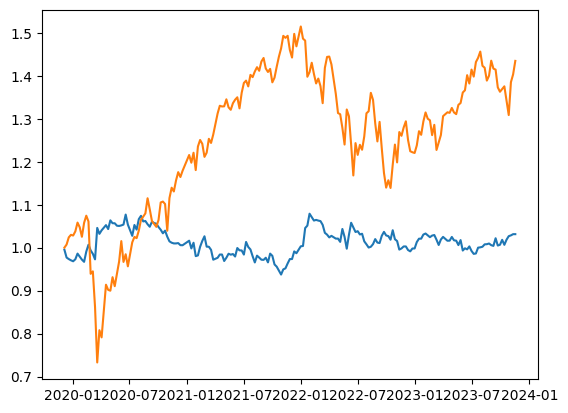

In [37]:
plt.plot(portfolio["date"].values,portfolio["cr"].values)
plt.plot(portfolio["date"].values,portfolio["bcr"].values)
plt.show()

In [38]:
recommendations = trades.tail(positions)

In [39]:
recommendations

,date,abs,direction,ticker,gics sector,adjclose,return,year,quarter,month,week,weekday
2189,2023-11-24 00:00:00+00:00,0.000975,-1.0,CMCSA,Communication Services,42.580000,NaN,2023,4,11,47,4
2190,2023-11-24 00:00:00+00:00,0.004723,-1.0,AMZN,Consumer Discretionary,146.740000,NaN,2023,4,11,47,4
2191,2023-11-24 00:00:00+00:00,0.002716,1.0,KO,Consumer Staples,58.112577,NaN,2023,4,11,47,4
2192,2023-11-24 00:00:00+00:00,0.010509,-1.0,CVX,Energy,144.900000,NaN,2023,4,11,47,4
2193,2023-11-24 00:00:00+00:00,0.003030,-1.0,MET,Financials,63.550000,NaN,2023,4,11,47,4
2194,2023-11-24 00:00:00+00:00,0.001017,-1.0,ABBV,Health Care,138.670000,NaN,2023,4,11,47,4
2195,2023-11-24 00:00:00+00:00,0.008684,-1.0,UNP,Industrials,224.280000,NaN,2023,4,11,47,4
2196,2023-11-24 00:00:00+00:00,0.017690,-1.0,CSCO,Information Technology,48.360000,NaN,2023,4,11,47,4
2197,2023-11-24 00:00:00+00:00,0.003821,1.0,DOW,Materials,50.974843,NaN,2023,4,11,47,4
2198,2023-11-24 00:00:00+00:00,0.009211,1.0,SPG,Real Estate,120.840000,NaN,2023,4,11,47,4


In [40]:
db.connect()
db.drop('portfolios')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",trades)
db.store("recommendations",recommendations)
db.disconnect()